    # Assignment 6 – Data Preprocessing and Model Building

## AIM
To perform Data Preprocessing and Model Building using Python 
on Heart Disease and Air Quality datasets.

## OBJECTIVES
- Understand concept of Data Preprocessing
- Perform Data Cleaning
- Perform Data Integration
- Perform Data Transformation
- Perform Error Correction
- Build Machine Learning Model

## What is Data Preprocessing?

Data preprocessing is the process of converting raw data into 
a clean and structured format suitable for machine learning.

Raw data may contain:
- Missing values
- Duplicate records
- Outliers
- Incorrect data types
- Categorical variables

Machine learning models require clean numerical data.

## Step 1: Import Required Libraries
We import pandas, numpy, matplotlib, seaborn and sklearn libraries.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## Step 2: Load the Datasets

We load:
- heart.csv (Heart Disease dataset)
- air_quality.csv (Air Quality dataset)

In [22]:
heart_df = pd.read_csv("heart.csv")
air_df = pd.read_csv("air_quality.csv")

heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [23]:
air_df.head()

,city,so2,no2,rspm,spm,pm2_5,type,state
0,Mumbai,20,40.0,100.0,200,60.0,RRO,Maharashtra
1,Delhi,50,NaN,200.0,350,120.0,I,Delhi
2,Pune,15,30.0,90.0,150,45.0,RO,Maharashtra
3,Chennai,30,35.0,NaN,180,80.0,S,Tamil Nadu
4,Kolkata,60,70.0,250.0,400,150.0,RRO,West Bengal


# Step 3: Data Cleaning (Heart Dataset)

Data cleaning involves:
- Checking data types
- Handling missing values
- Removing duplicates
- Detecting outliers

In [24]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       21 non-null     int64  
 1   sex       21 non-null     int64  
 2   cp        21 non-null     int64  
 3   trestbps  21 non-null     int64  
 4   chol      21 non-null     int64  
 5   fbs       21 non-null     int64  
 6   restecg   21 non-null     int64  
 7   thalach   21 non-null     int64  
 8   exang     21 non-null     int64  
 9   oldpeak   21 non-null     float64
 10  slope     21 non-null     int64  
 11  ca        21 non-null     int64  
 12  thal      21 non-null     int64  
 13  target    21 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 2.4 KB


We observe that categorical columns are stored as integers.
We convert them to 'object' type for better interpretation.

In [25]:
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

for col in categorical_cols:
    heart_df[col] = heart_df[col].astype('object')

heart_df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs          object
restecg      object
thalach       int64
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
target        int64
dtype: object

In [26]:
heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

If missing values are present, we replace them using median.
Median is preferred because it is robust to outliers.

In [27]:
heart_df = heart_df.fillna(heart_df.median(numeric_only=True))

In [28]:
heart_df.duplicated().sum()
heart_df = heart_df.drop_duplicates()

We use Boxplot to visually detect outliers in cholesterol.

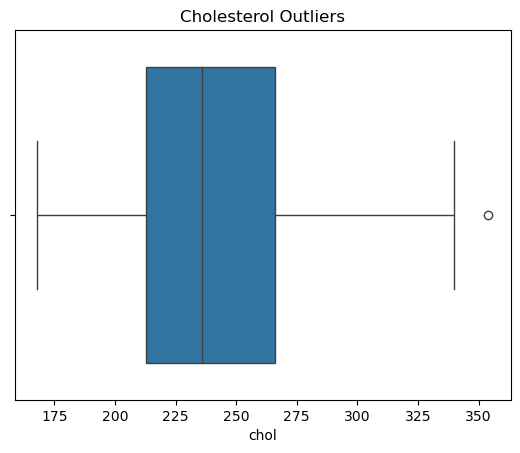

In [29]:
sns.boxplot(x=heart_df['chol'])
plt.title("Cholesterol Outliers")
plt.show()

IQR Method:
IQR = Q3 - Q1
Remove values outside:
Q1 - 1.5*IQR and Q3 + 1.5*IQR

In [30]:
Q1 = heart_df['chol'].quantile(0.25)
Q3 = heart_df['chol'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

heart_df = heart_df[(heart_df['chol'] >= lower) & 
                    (heart_df['chol'] <= upper)]

# Step 4: Data Cleaning (Air Quality Dataset)

We handle:
- Missing values
- Categorical encoding

In [31]:
air_df.isnull().sum()

city     0
so2      0
no2      1
rspm     1
spm      0
pm2_5    1
type     0
state    0
dtype: int64

Fill missing pollution values using mean.

In [32]:
pollution_cols = ['so2','no2','rspm','spm','pm2_5']

for col in pollution_cols:
    air_df[col] = air_df[col].fillna(air_df[col].mean())

# Step 5: Data Transformation

Machine learning requires numerical inputs.
We encode categorical variables.

In [33]:
heart_df = pd.get_dummies(heart_df, drop_first=True)
heart_df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,fbs_1,restecg_1,exang_1,slope_1,slope_2,ca_2,thal_2,thal_3
0,63,145,233,150,2.3,1,True,False,False,True,True,False,False,False,False,False,False,False
1,37,130,250,187,3.5,1,True,False,True,False,False,True,False,False,False,False,True,False
2,41,130,204,172,1.4,1,False,True,False,False,False,False,False,False,True,False,True,False
3,56,120,236,178,0.8,1,True,True,False,False,False,True,False,False,True,False,True,False
5,57,140,192,148,0.4,1,True,False,False,False,False,True,False,True,False,False,False,False


Feature scaling ensures all variables are on same scale.
Formula:
(x - mean) / standard deviation

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(heart_df.drop('target', axis=1))

# Step 6: Define Features (X) and Target (y)

In [35]:
X = heart_df.drop('target', axis=1)
y = heart_df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 17)
y shape: (20,)


# Step 7: Train-Test Split (80:20)

80% for training
20% for testing

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Model Building

We use Decision Tree Classifier because:
- Target variable is binary (0 or 1)
- Works well with mixed data types

In [37]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Step 9: Model Evaluation

Accuracy = Correct Predictions / Total Predictions

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.25
Confusion Matrix:
[[0 0]
 [3 1]]


## Supervised Learning
Uses labeled data.
Example: Heart Disease prediction (Classification)

Types:
- Classification → Predict category
- Regression → Predict numerical value

## Unsupervised Learning
Uses unlabeled data.
Example:
- Clustering
- Association rule mining

# Conclusion

In this assignment, we performed:

- Data Cleaning
- Missing Value Treatment
- Duplicate Removal
- Outlier Detection
- Data Transformation
- Feature Scaling
- Train-Test Split
- Decision Tree Model Building
- Model Evaluation

Data preprocessing is the most important step in Machine Learning,
because model performance depends heavily on data quality.